# 04 Multimodal Model

Goal: train a simple two-branch model using the same grouped split as the metadata baseline.

Architecture:

`image -> CNN encoder -> image embedding`

`metadata -> one-hot encoding -> metadata MLP -> metadata embedding`

`concatenate -> dense layer -> binary classifier`

Notes:
- You must update the path where you have the Great_UK_WaterBlitz folder on your local PC
- This model had the CNN encoder frozen; future improvements should unfreeze this (though training will require much more compute)
- The MLP one/multi-hot encoding can be improved; I started trying to do this in 04b_multimodal_model_multihot.ipynb but never finished it.

In [10]:
from pathlib import Path

# Set this to the folder containing the downloaded image files.
IMAGE_DIR = Path(r"C:\Users\lukem\Downloads\Great_UK_WaterBlitz\Great_UK_WaterBlitz")
if not IMAGE_DIR.is_dir():
    raise FileNotFoundError(f"Image directory does not exist: {IMAGE_DIR}")

IMAGE_DIR

WindowsPath('C:/Users/lukem/Downloads/Great_UK_WaterBlitz/Great_UK_WaterBlitz')

In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image, ImageOps
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

try:
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, Dataset
    import torchvision.transforms as transforms
    from torchvision import models
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        'This notebook needs torch and torchvision. Select a torch-enabled kernel or install the project requirements.'
    ) from exc

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'src' else Path.cwd()
DATA_PATH = PROJECT_ROOT / 'data' / 'audited_metadata_with_split.csv'
OUT_DIR = PROJECT_ROOT / 'outputs'
OUT_DIR.mkdir(exist_ok=True)

SAFE_METADATA_FEATURES = [
    'Freshwater body type',
    'What is the main land use within 50m?',
    'What is the main bank vegetation? (select all that apply)',
    'Is there any of the following on the water surface?',
    'Estimate the water colour',
]

TARGET = 'binary_label'
TARGET_NAMES = ['Acceptable', 'Unacceptable']
BATCH_SIZE = 32
NUM_EPOCHS = 12
LR_HEAD = 1e-4
LR_IMAGE = 1e-5
WEIGHT_DECAY = 1e-4
PATIENCE = 3
FREEZE_IMAGE_ENCODER = True
CHECKPOINT_PATH = OUT_DIR / 'best_multimodal_model.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device


device(type='cpu')

## Load Data And Check Split

In [12]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df['binary_label'] = df['binary_label'].astype(int)
df = df[df['saved_filename'].notna()].copy()
df['local_image_path'] = df['saved_filename'].map(
    lambda filename: IMAGE_DIR / Path(str(filename)).name
)
df['image_exists'] = df['local_image_path'].map(Path.is_file)

missing_paths = df.loc[~df['image_exists'], 'local_image_path']
print(f'Images found: {df["image_exists"].sum():,} / {len(df):,}')
if not missing_paths.empty:
    print('First missing image paths:')
    print(missing_paths.head().to_string(index=False))
    raise FileNotFoundError(
        f'{len(missing_paths):,} image files are missing from {IMAGE_DIR}'
    )

train_df = df[df['split'].eq('train')].copy().reset_index(drop=True)
val_df = df[df['split'].eq('val')].copy().reset_index(drop=True)

print(df['split'].value_counts())
print(pd.crosstab(df['split'], df['binary_label_name']))

train_groups = set(train_df['GlobalID'])
val_groups = set(val_df['GlobalID'])
print('Overlapping GlobalIDs:', len(train_groups & val_groups))

Images found: 8,996 / 8,996
split
train    7200
val      1796
Name: count, dtype: int64
binary_label_name  Acceptable  Unacceptable
split                                      
train                    2617          4583
val                       641          1155
Overlapping GlobalIDs: 0


## Metadata Encoding

In [13]:
metadata_preprocess = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
            ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
        ]), SAFE_METADATA_FEATURES),
    ]
)

X_meta_train = metadata_preprocess.fit_transform(train_df[SAFE_METADATA_FEATURES]).astype('float32')
X_meta_val = metadata_preprocess.transform(val_df[SAFE_METADATA_FEATURES]).astype('float32')

print('Train metadata matrix:', X_meta_train.shape)
print('Val metadata matrix:', X_meta_val.shape)

Train metadata matrix: (7200, 122)
Val metadata matrix: (1796, 122)


## Image Dataset Preview

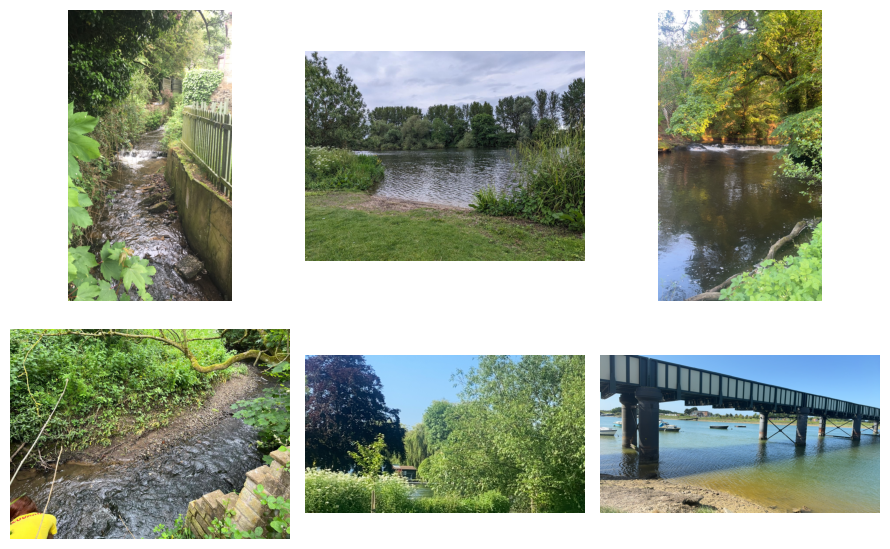

In [14]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, scale=(0.75, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=10),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

preview_paths = train_df['local_image_path'].head(6).tolist()
fig, axes = plt.subplots(2, 3, figsize=(9, 6))
for ax, path in zip(axes.ravel(), preview_paths):
    img = ImageOps.exif_transpose(Image.open(path)).convert('RGB')
    ax.imshow(img)
    ax.axis('off')
plt.tight_layout()
plt.show()


## Dataset And Dataloaders

In [15]:
class EarthwatchMultimodalDataset(Dataset):
    def __init__(self, frame, metadata_matrix, transform):
        self.frame = frame.reset_index(drop=True)
        self.metadata_matrix = metadata_matrix
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, idx):
        row = self.frame.iloc[idx]
        image = Image.open(row['local_image_path'])
        image = ImageOps.exif_transpose(image).convert('RGB')
        image = self.transform(image)
        metadata = torch.tensor(self.metadata_matrix[idx], dtype=torch.float32)
        label = torch.tensor(int(row[TARGET]), dtype=torch.long)
        return image, metadata, label

train_ds = EarthwatchMultimodalDataset(train_df, X_meta_train, train_transform)
val_ds = EarthwatchMultimodalDataset(val_df, X_meta_val, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

batch = next(iter(train_loader))
print('Image batch:', batch[0].shape)
print('Metadata batch:', batch[1].shape)
print('Label batch:', batch[2].shape)

Image batch: torch.Size([32, 3, 224, 224])
Metadata batch: torch.Size([32, 122])
Label batch: torch.Size([32])


## Model

In [16]:
class MultimodalClassifier(nn.Module):
    def __init__(self, metadata_dim, num_classes=2, freeze_image_encoder=True):
        super().__init__()
        try:
            weights = models.ResNet18_Weights.DEFAULT
            image_model = models.resnet18(weights=weights)
        except Exception:
            image_model = models.resnet18(weights=None)

        image_dim = image_model.fc.in_features
        image_model.fc = nn.Identity()
        self.image_encoder = image_model
        self.freeze_image_encoder = freeze_image_encoder

        if freeze_image_encoder:
            for parameter in self.image_encoder.parameters():
                parameter.requires_grad = False

        self.metadata_encoder = nn.Sequential(
            nn.Linear(metadata_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Linear(image_dim + 64, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes),
        )

    def forward(self, image, metadata):
        image_embedding = self.image_encoder(image)
        metadata_embedding = self.metadata_encoder(metadata)
        combined = torch.cat([image_embedding, metadata_embedding], dim=1)
        return self.classifier(combined)

model = MultimodalClassifier(
    metadata_dim=X_meta_train.shape[1],
    freeze_image_encoder=FREEZE_IMAGE_ENCODER,
).to(device)

class_counts = np.bincount(train_df[TARGET].to_numpy(), minlength=len(TARGET_NAMES))
class_weights = class_counts.sum() / (len(TARGET_NAMES) * class_counts)
class_weights = torch.tensor(class_weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer_groups = [
    {'params': model.metadata_encoder.parameters(), 'lr': LR_HEAD},
    {'params': model.classifier.parameters(), 'lr': LR_HEAD},
]
if not FREEZE_IMAGE_ENCODER:
    optimizer_groups.insert(0, {'params': model.image_encoder.parameters(), 'lr': LR_IMAGE})

optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=WEIGHT_DECAY)

trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
rounded_weights = np.round(class_weights.detach().cpu().numpy(), 3)
print('Class weights:', dict(zip(TARGET_NAMES, rounded_weights.tolist())))
print(f'Trainable parameters: {trainable_params:,} / {total_params:,}')


1.1%

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\lukem/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100.0%


Class weights: {'Acceptable': 1.3760000467300415, 'Unacceptable': 0.7860000133514404}
Trainable parameters: 98,114 / 11,274,626


## Training And Evaluation

In [17]:
def run_epoch(loader, training):
    model.train(training)
    if training and FREEZE_IMAGE_ENCODER:
        model.image_encoder.eval()

    total_loss = 0.0
    all_preds = []
    all_labels = []

    for images, metadata, labels in loader:
        images = images.to(device)
        metadata = metadata.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(training):
            logits = model(images, metadata)
            loss = criterion(logits, labels)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        total_loss += loss.item() * labels.size(0)
        all_preds.extend(logits.argmax(dim=1).detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    avg_loss = total_loss / len(loader.dataset)
    bal_acc = balanced_accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average='macro')
    return avg_loss, bal_acc, macro_f1, np.array(all_labels), np.array(all_preds)

history = []
best_val_f1 = -np.inf
best_epoch = None
patience_left = PATIENCE
best_y_true = None
best_y_pred = None

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_bal_acc, train_f1, _, _ = run_epoch(train_loader, training=True)
    val_loss, val_bal_acc, val_f1, y_true_epoch, y_pred_epoch = run_epoch(val_loader, training=False)
    improved = val_f1 > best_val_f1

    history.append({
        'epoch': epoch,
        'train_loss': train_loss,
        'train_bal_acc': train_bal_acc,
        'train_macro_f1': train_f1,
        'val_loss': val_loss,
        'val_bal_acc': val_bal_acc,
        'val_macro_f1': val_f1,
        'best_so_far': improved,
    })

    print(
        f"Epoch {epoch}: train_loss={train_loss:.4f} val_loss={val_loss:.4f} "
        f"val_bal_acc={val_bal_acc:.4f} val_macro_f1={val_f1:.4f}"
    )

    if improved:
        best_val_f1 = val_f1
        best_epoch = epoch
        best_y_true = y_true_epoch
        best_y_pred = y_pred_epoch
        patience_left = PATIENCE
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_macro_f1': val_f1,
            'val_bal_acc': val_bal_acc,
            'config': {
                'freeze_image_encoder': FREEZE_IMAGE_ENCODER,
                'lr_head': LR_HEAD,
                'lr_image': LR_IMAGE,
                'weight_decay': WEIGHT_DECAY,
                'class_weights': class_weights.detach().cpu().tolist(),
            },
        }, CHECKPOINT_PATH)
        print(f'  Saved new best checkpoint to {CHECKPOINT_PATH}')
    else:
        patience_left -= 1
        if patience_left == 0:
            print(f'Early stopping after {epoch} epochs. Best epoch: {best_epoch} with val_macro_f1={best_val_f1:.4f}')
            break

history_df = pd.DataFrame(history)
y_true = best_y_true
y_pred = best_y_pred
print(f'Best epoch: {best_epoch}; best val_macro_f1={best_val_f1:.4f}')
history_df


KeyboardInterrupt: 

^the above block could take 1-4hrs on cpu or 5-20 mins on gpu. Earlier if early stoppage.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
history_df.plot(x='epoch', y=['train_loss', 'val_loss'], ax=axes[0], marker='o')
history_df.plot(x='epoch', y=['train_bal_acc', 'val_bal_acc', 'train_macro_f1', 'val_macro_f1'], ax=axes[1], marker='o')
axes[0].set_title('Loss')
axes[1].set_title('Balanced Accuracy / Macro F1')
plt.tight_layout()
plt.show()

print(classification_report(y_true, y_pred, target_names=TARGET_NAMES, zero_division=0))
cm = confusion_matrix(y_true, y_pred)
ConfusionMatrixDisplay(cm, display_labels=TARGET_NAMES).plot(values_format='d', cmap='Blues')
plt.title('Multimodal validation confusion matrix')
plt.show()